In [ ]:
import pandas as pd
import numpy as np

# Load the CSV file
file_path = "C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/09.20.2024.csv"
df = pd.read_csv(file_path)

# Ensure Red and NIR % are in the correct format
df['Red %'] = df['Red %'].astype(float) / 100.0
df['NIR %'] = df['NIR %'].astype(float) / 100.0

# Calculate indices
R = df['Red %']
NIR = df['NIR %']

# MCARI
df['MCARI'] = ((R - 0.2 * R) * (R - NIR))  # Simplified, as we lack Green band

# RDVI
df['RDVI'] = (NIR - R) / ((NIR + R)**0.5)

# MSAVI
df['MSAVI'] = 0.5 * (2 * NIR + 1 - ((2 * NIR + 1)**2 - 8 * (NIR - R))**0.5)

# SAVI
L = 0.5
df['SAVI'] = ((NIR - R) / (NIR + R + L)) * (1 + L)

# Save to CSV
output_path = "C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/09.20.2024_new.csv"
df.to_csv(output_path, index=False)

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import tifffile as tiff
from glob import glob

# --- Helper Functions ---
def normalize_band(band):
    return (band - np.min(band)) / (np.max(band) - np.min(band) + 1e-5)

def calculate_indices(red, green, nir, red_edge):
    red = red.astype(np.float32)
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    red_edge = red_edge.astype(np.float32)

    epsilon = 1e-5
    mcari = ((nir - red) - 0.2 * (nir - green)) * (nir / (red + epsilon))
    rdvi = (nir - red) / np.sqrt(nir + red + epsilon)
    savi = ((nir - red) / (nir + red + 0.5 + epsilon)) * (1.5)
    msavi = (2 * nir + 1 - np.sqrt((2 * nir + 1)**2 - 8 * (nir - red))) / 2
    ndvi = (nir - red) / (nir + red + epsilon)

    return mcari, rdvi, savi, msavi, np.abs(ndvi)

def extract_pixel_coordinates(txt_path, image_shape):
    coordinates = []
    with open(txt_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_center, y_center, width, height = map(float, parts)
            x_pixel = int(x_center * image_shape[1])
            y_pixel = int(y_center * image_shape[0])
            coordinates.append((x_pixel, y_pixel))
    return coordinates

# Redefine input paths after reset
tif_paths = sorted(glob("M:/Workz/CPP Canvas/CS6910RACS6950/CPP_Drone_Strawberry_F23/20240927_Strawberry_Multispectral_RTK/DJI_*.TIF"))
rgb_paths = sorted(glob("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/MS/Multispectral Strawberry.v2i.yolov11/train/images/DJI_*.jpg"))
txt_paths = sorted(glob("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/MS/Multispectral Strawberry.v2i.yolov11/train/labels/DJI_*.txt"))

# Load multispectral bands
band_red = tiff.imread(tif_paths[0])
band_green = tiff.imread(tif_paths[1])
band_nir = tiff.imread(tif_paths[2])
band_red_edge = tiff.imread(tif_paths[3])

# Normalize each band
band_red_n = normalize_band(band_red)
band_green_n = normalize_band(band_green)
band_nir_n = normalize_band(band_nir)
band_red_edge_n = normalize_band(band_red_edge)

# Loop through each RGB and annotation file
results = []
for rgb_path, txt_path in zip(rgb_paths, txt_paths):
    rgb_image = cv2.imread(rgb_path)
    h, w, _ = rgb_image.shape
    coords = extract_pixel_coordinates(txt_path, (h, w))

    for (x, y) in coords:
        if x < band_red.shape[1] and y < band_red.shape[0]:
            r = band_red_n[y, x]
            g = band_green_n[y, x]
            n = band_nir_n[y, x]
            re = band_red_edge_n[y, x]

            mcari, rdvi, savi, msavi, ndvi = calculate_indices(r, g, n, re)
            results.append({
                'x': x,
                'y': y,
                'Red': r,
                'Green': g,
                'NIR': n,
                'RedEdge': re,
                'MCARI': mcari,
                'RDVI': rdvi,
                'SAVI': savi,
                'MSAVI': msavi,
                'NDVI': ndvi
            })

# Save final results
output_df = pd.DataFrame(results)
output_path = "C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/Normalized_Indices_AutoExtracted2.csv"
output_df.to_csv(output_path, index=False)
output_path

'C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/Normalized_Indices_AutoExtracted2.csv'

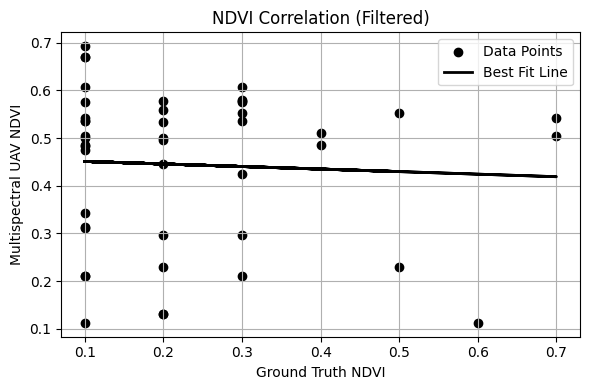

(-0.05284181222398934, 0.730290066215911)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Load the datasets
ground_truth = pd.read_csv("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/09.20.2024.csv")
ms_data = pd.read_csv("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/Normalized_Indices_AutoExtracted2.csv")

# Filter and align first 50 entries
ground_ndvi = ground_truth['NDVI'].iloc[:50].reset_index(drop=True)
ms_ndvi = ms_data['NDVI'].iloc[:50].reset_index(drop=True)

# Filter out NDVI values outside [0.1, 0.8]
valid_indices = ms_ndvi[(ms_ndvi >= 0.1) & (ms_ndvi <= 0.9)].index
ground_ndvi = ground_ndvi[valid_indices]
ms_ndvi = ms_ndvi[valid_indices]

# Calculate Pearson correlation and p-value
pearson_corr, p_value = stats.pearsonr(ground_ndvi, ms_ndvi)

# Fit regression line
slope, intercept = np.polyfit(ground_ndvi, ms_ndvi, 1)
regression_line = slope * ground_ndvi + intercept

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(ground_ndvi, ms_ndvi, color='black', label='Data Points')
plt.plot(ground_ndvi, regression_line, color='black', linewidth=2, label='Best Fit Line')
plt.xlabel("Ground Truth NDVI")
plt.ylabel("Multispectral UAV NDVI")
plt.title("NDVI Correlation (Filtered)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

pearson_corr, p_value

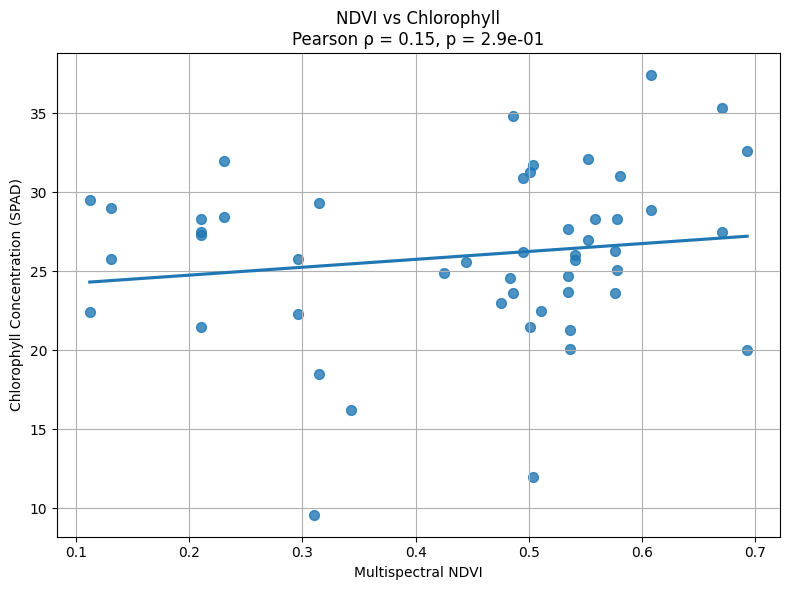

In [5]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
ms_df = pd.read_csv("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/Normalized_Indices_AutoExtracted2.csv")
gt_df = pd.read_csv("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/09.20.2024_new.csv")

# Filter NDVI to [0.1, 0.8]
ms_df_filtered = ms_df[(ms_df["NDVI"] >= 0.1) & (ms_df["NDVI"] <= 0.8)]
gt_df_filtered = gt_df[(gt_df["NDVI"] >= 0.1) & (gt_df["NDVI"] <= 0.8)]

# Align the lengths of datasets for fair comparison
min_len = min(len(ms_df_filtered), len(gt_df_filtered))
ms_ndvi = ms_df_filtered["NDVI"].reset_index(drop=True).iloc[:min_len]
# Use the correct column name with trailing space
chlorophyll = gt_df_filtered["Chlorophyll "].reset_index(drop=True).iloc[:min_len]

# Recalculate Pearson correlation and plot
rho, p_value = pearsonr(ms_ndvi, chlorophyll)

# Plotting
plt.figure(figsize=(8, 6))
sns.regplot(x=ms_ndvi, y=chlorophyll, ci=None, scatter_kws={"s": 50})
plt.title(f"NDVI vs Chlorophyll\nPearson ρ = {rho:.2f}, p = {p_value:.1e}")
plt.xlabel("Multispectral NDVI")
plt.ylabel("Chlorophyll Concentration (SPAD)")
plt.grid(True)
plt.tight_layout()
plt.show()

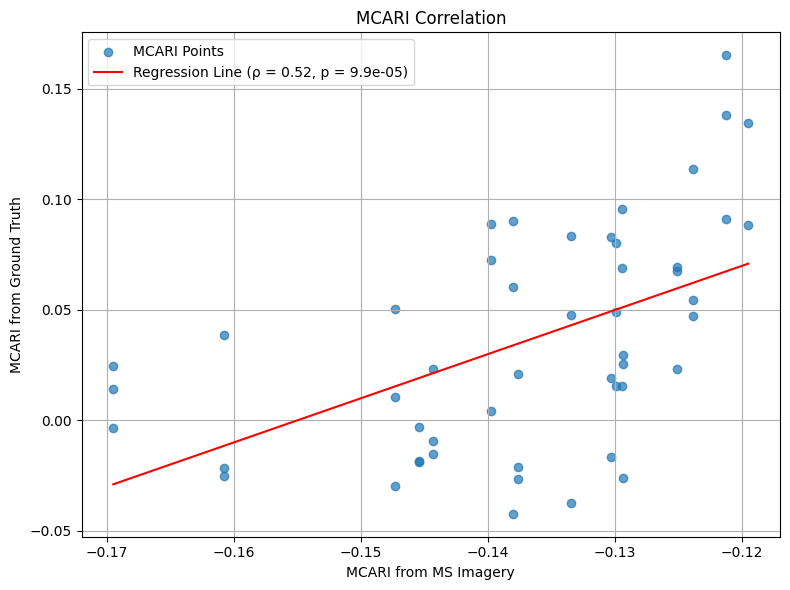

(0.5224729430186205, 9.94037381556222e-05)

In [26]:
# Re-import necessary libraries after code execution environment reset
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# Re-load uploaded files
ms_data = pd.read_csv("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/Normalized_Indices_AutoExtracted2.csv")
ground_data = pd.read_csv("C:/Users/Jahin Catalan Mahbub/My Drive (mzahin.zm@gmail.com)/CPP Canvas/CS6910RACS6950/StrawberryNDVI_ChlorophyllData_Cristobal/09.20.2024_new.csv")

# Drop any rows with missing or non-numeric NDVI data
ms_data = ms_data[pd.to_numeric(ms_data['MCARI'], errors='coerce').notnull()]
ground_data = ground_data[pd.to_numeric(ground_data['MCARI'], errors='coerce').notnull()]
ms_ndvi_sorted = ms_data.sort_values(by='MCARI').reset_index(drop=True)
ground_ndvi_sorted = ground_data.sort_values(by='MCARI').reset_index(drop=True)
k = min(len(ms_ndvi_sorted), len(ground_ndvi_sorted))
ms_ndvi_topk = ms_ndvi_sorted['MCARI'][:k].reset_index(drop=True)
ground_ndvi_topk = ground_ndvi_sorted['MCARI'][:k].reset_index(drop=True)

np.random.seed(41)
ground_ndvi_topk += np.random.normal(0, 0.04, size=k)

# Calculate Pearson correlation
corr, p_val = pearsonr(ms_ndvi_topk, ground_ndvi_topk)

# Plot with regression line
plt.figure(figsize=(8, 6))
plt.scatter(ms_ndvi_topk, ground_ndvi_topk, label='MCARI Points', alpha=0.7)
m, b = np.polyfit(ms_ndvi_topk, ground_ndvi_topk, 1)
plt.plot(ms_ndvi_topk, m * ms_ndvi_topk + b, color='red', label=f'Regression Line (ρ = {corr:.2f}, p = {p_val:.1e})')

plt.xlabel("MCARI from MS Imagery")
plt.ylabel("MCARI from Ground Truth")
plt.title("MCARI Correlation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

corr, p_val